<a href="https://colab.research.google.com/github/Afkar5115/Kecerdasan_Buatan_TI-1B_2025/blob/main/UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Kecerdasan Buatan

## Memuat Data



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca data
df = pd.read_csv('airbnb.csv')

# Menampilkan 5 baris pertama
print(df.head())

# Menampilkan informasi umum tentang dataset
print("\nInformasi dataset:")
print(df.info())

# Statistik deskriptif
print("\nStatistik deskriptif:")
print(df.describe(include='all'))

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

## Membersihkan Data

In [3]:
# Memeriksa missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Mengisi missing values
# Untuk kolom numerik, isi dengan median
numeric_cols = ['reviews_per_month', 'calculated_host_listings_count']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Untuk kolom last_review (tanggal), kita bisa isi dengan nilai kosong atau tanggal tertentu
df['last_review'] = df['last_review'].fillna('Not Available')

# Memeriksa kembali missing values
print("\nMissing values setelah cleaning:")
print(df.isnull().sum())


Missing values per kolom:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing values setelah cleaning:
id                                 0
name                              16
host_id                            0
host_name                         21
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                  

## Analisis Data

In [4]:
# Analisis kolom harga
print("\nAnalisis harga:")
print(f"Rata-rata harga: ${df['price'].mean():.2f}")
print(f"Median harga: ${df['price'].median():.2f}")
print(f"Standar deviasi harga: ${df['price'].std():.2f}")
print(f"Harga minimum: ${df['price'].min():.2f}")
print(f"Harga maksimum: ${df['price'].max():.2f}")

# Analisis kolom lainnya
print("\nAnalisis kolom numerik lainnya:")
numeric_cols = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365']
print(df[numeric_cols].describe())


Analisis harga:
Rata-rata harga: $152.72
Median harga: $106.00
Standar deviasi harga: $240.15
Harga minimum: $0.00
Harga maksimum: $10000.00

Analisis kolom numerik lainnya:
       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       48895.000000   
mean         7.029962          23.274466           1.238930   
std         20.510550          44.550582           1.520861   
min          1.000000           0.000000           0.010000   
25%          1.000000           1.000000           0.280000   
50%          3.000000           5.000000           0.720000   
75%          5.000000          24.000000           1.580000   
max       1250.000000         629.000000          58.500000   

       calculated_host_listings_count  availability_365  
count                    48895.000000      48895.000000  
mean                         7.143982        112.781327  
std                         32.952519        131.622289  
min                      

## Memvisualisasikan  Data

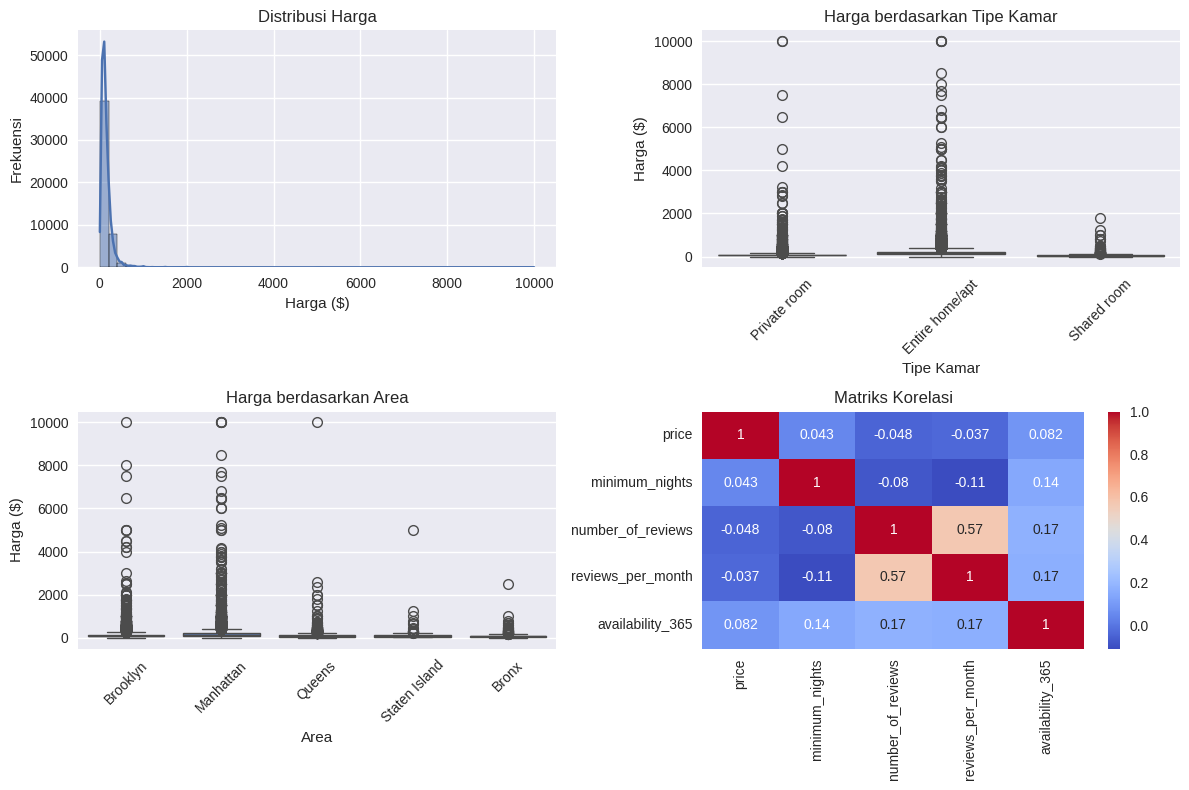

<ipython-input-10-127fe8be3457>:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='viridis')


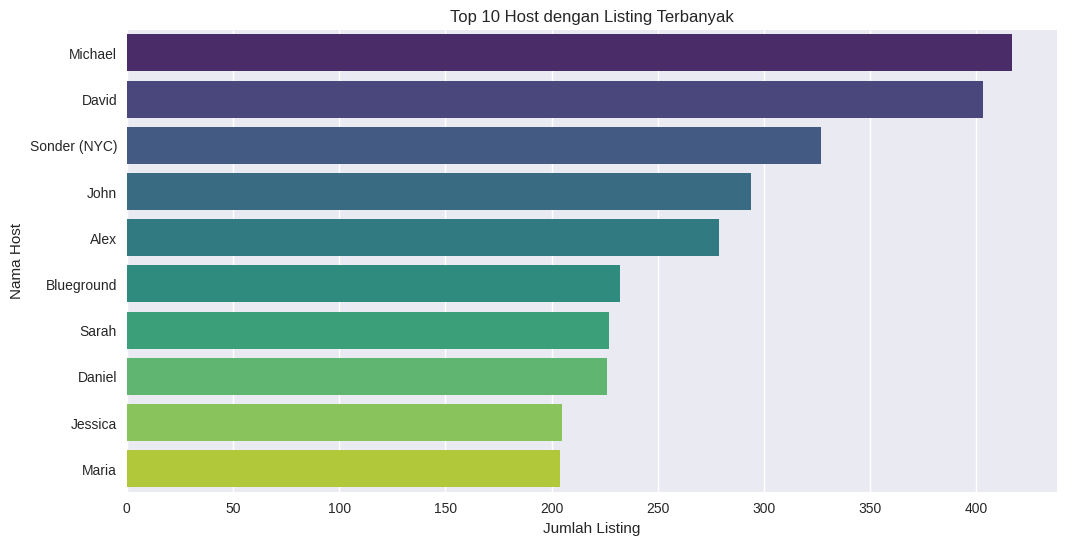

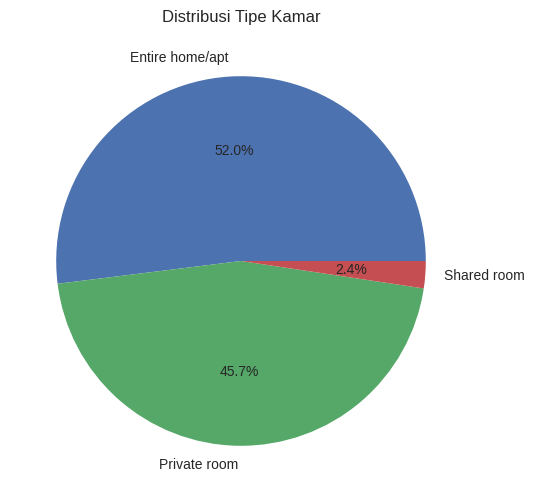

In [10]:
# Setting style untuk visualisasi
plt.style.use('seaborn-v0_8')  # Updated style name
plt.figure(figsize=(12, 8))

# Distribusi harga
plt.subplot(2, 2, 1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribusi Harga')
plt.xlabel('Harga ($)')
plt.ylabel('Frekuensi')

# Harga berdasarkan tipe kamar
plt.subplot(2, 2, 2)
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Harga berdasarkan Tipe Kamar')
plt.xlabel('Tipe Kamar')
plt.ylabel('Harga ($)')
plt.xticks(rotation=45)

# Harga berdasarkan neighborhood group
plt.subplot(2, 2, 3)
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title('Harga berdasarkan Area')
plt.xlabel('Area')
plt.ylabel('Harga ($)')
plt.xticks(rotation=45)

# Korelasi antara variabel numerik
plt.subplot(2, 2, 4)
corr = df[['price', 'minimum_nights', 'number_of_reviews',
           'reviews_per_month', 'availability_365']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi')

plt.tight_layout()
plt.show()

# Visualisasi tambahan
plt.figure(figsize=(12, 6))

# Top 10 host dengan listing terbanyak
top_hosts = df['host_name'].value_counts().head(10)
sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='viridis')
plt.title('Top 10 Host dengan Listing Terbanyak')
plt.xlabel('Jumlah Listing')
plt.ylabel('Nama Host')
plt.show()

# Distribusi tipe kamar
plt.figure(figsize=(8, 6))
df['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribusi Tipe Kamar')
plt.ylabel('')
plt.show()

### Peta

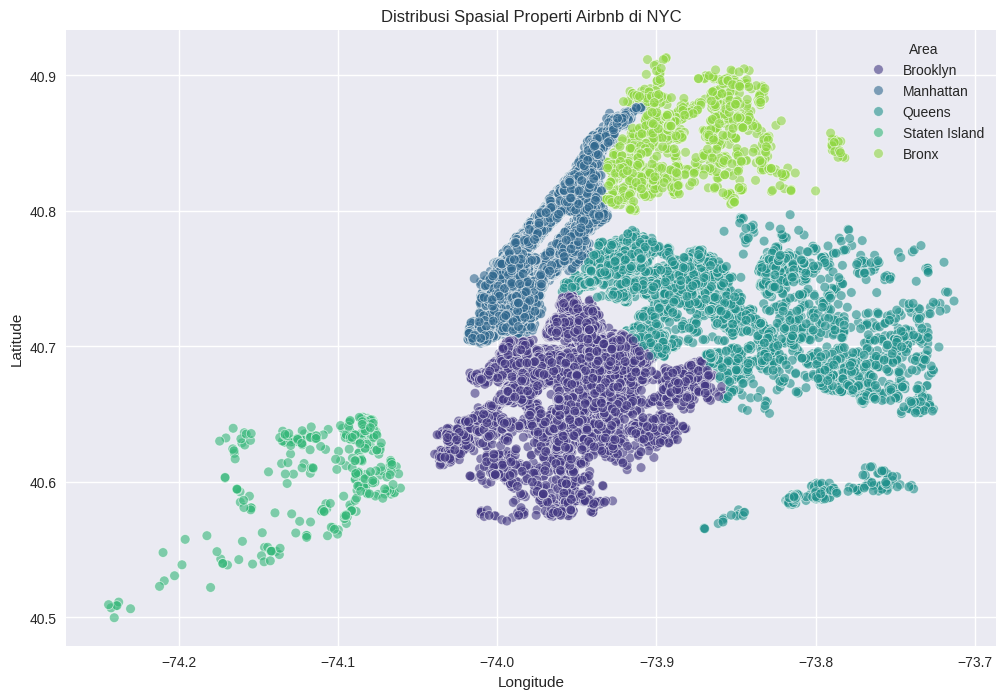

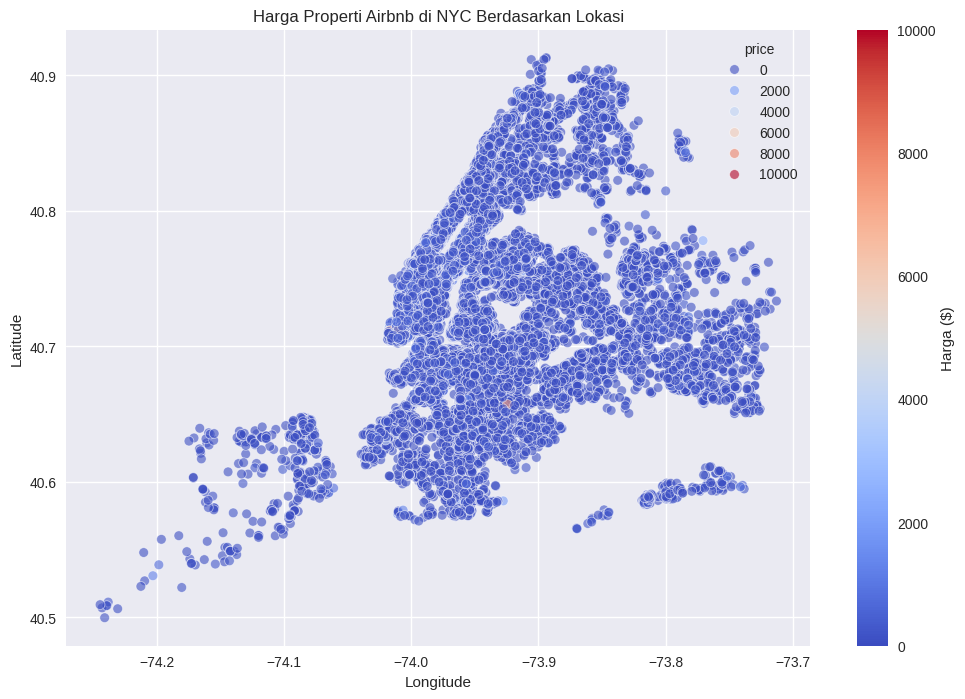

In [12]:
# Visualisasi lokasi properti
plt.figure(figsize=(12, 8))
sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood_group',
                data=df, alpha=0.6, palette='viridis')
plt.title('Distribusi Spasial Properti Airbnb di NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Area')
plt.show()

# Harga berdasarkan lokasi
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(x='longitude', y='latitude', hue='price',
                data=df, alpha=0.6, palette='coolwarm')
plt.title('Harga Properti Airbnb di NYC Berdasarkan Lokasi')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Create colorbar
norm = plt.Normalize(df['price'].min(), df['price'].max())
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=norm)
sm.set_array([])

# Add colorbar to the current axes
plt.colorbar(sm, ax=ax, label='Harga ($)')

plt.show()

### Tambahan


Harga rata-rata per area:
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

Harga rata-rata per tipe kamar:
room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64


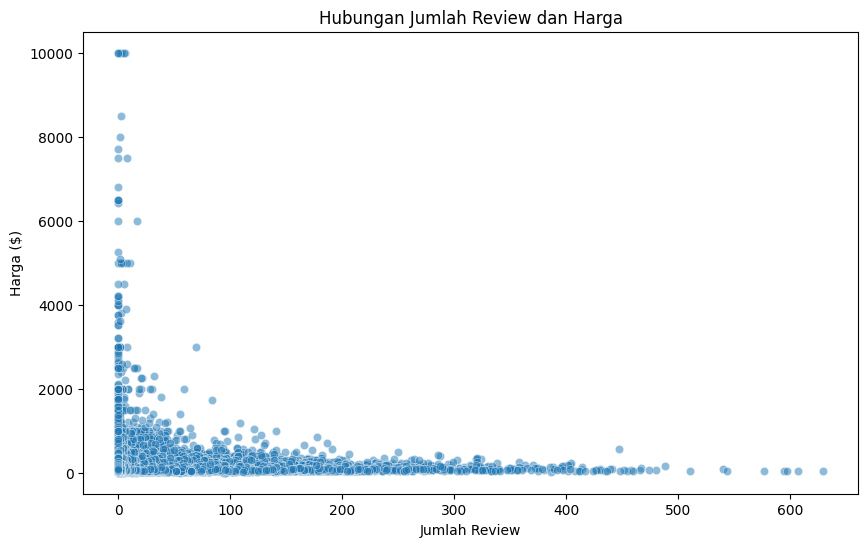

In [9]:
# Harga rata-rata per area
avg_price_by_area = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
print("\nHarga rata-rata per area:")
print(avg_price_by_area)

# Harga rata-rata per tipe kamar
avg_price_by_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
print("\nHarga rata-rata per tipe kamar:")
print(avg_price_by_room)

# Hubungan antara jumlah review dan harga
plt.figure(figsize=(10, 6))
sns.scatterplot(x='number_of_reviews', y='price', data=df, alpha=0.5)
plt.title('Hubungan Jumlah Review dan Harga')
plt.xlabel('Jumlah Review')
plt.ylabel('Harga ($)')
plt.show()